In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
import pandas as pd

# Simulation details

I first define the internal units for the simulation. I want it to be similar to a star and I want to use $N \sim 80-100$ particles, so I will set $1 \ M[IU] = 0.01 \ M_\odot = 2 \times 10^{31} \ g$ and $L \ [IU] = 1 \ R_\odot = 7 \times 10^{10} \ cm$. The time unit will be $T \ [IU] = 16035 \ s$. I will use a precision d=0.01 and print a timestamp every 0.01 IU.

# Inverse transform sampling

The pdf to sample from has the following form:

$p(\vec{x}) \propto r^2 sin(\theta) $ 

so, uniform in $\phi$, but not in $r$ and $\theta$. This is just the product of distinct distributions $p(\vec{x})=p_1(r) \cdot p_2(\theta) \cdot p_3(\phi)$. I want to sample $r \in [0.1, 2]$, $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi]$. Therefore to normalize I will set:

$p_1(r) = \frac{3}{8-0.1^3} \cdot r^2$

$p_2(\theta) = \frac{1}{2} sin(\theta)$

$p_3(\phi) = \frac{1}{2\pi}$

The CDF can be computed analytically in all cases:

$H_1(r)=\frac{r^3}{8-0.1^3}$

$H_2(\theta)=-\frac{1}{2}cos(\theta)+\frac{1}{2}$

$H_3(\phi)=\frac{1}{2\pi}\phi$

So that:

$r = [(8-0.1^3)\cdot H_1]^{\frac{1}{3}}$

$\theta = arccos(1-2H_2)$

$\phi=2\pi H_3$

Now let's sample and invert.

In [135]:
N_points = 90
rmin = 0
rmax = 1
dr3 = rmax**3 - rmin**3

h1 = uniform.rvs(loc=0, scale=1, size=N_points)
h2 = uniform.rvs(loc=0, scale=1, size=N_points)
h3 = uniform.rvs(loc=0, scale=1, size=N_points)

r = (h1 * dr3) ** (1/3)
theta = np.arccos(1 - 2 * h2)
phi = 2*np.pi*h3

In [136]:
rho = N_points / (4/3 * np.pi * dr3)
exp_time = np.sqrt((3*np.pi)/(32*rho))
print(exp_time)

0.11708024551734543


Text(0.5, 0, 'r [UI]')

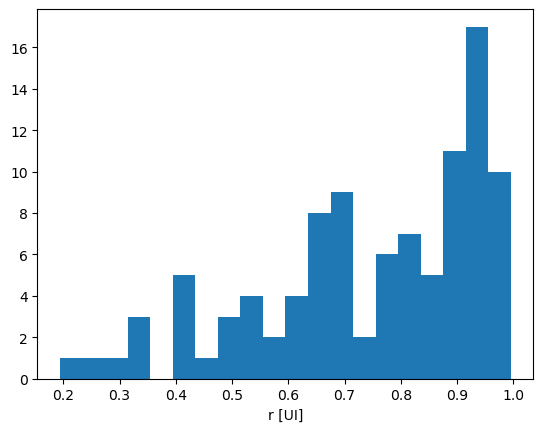

In [35]:
fig, ax = plt.subplots()
plt.hist(r, bins=20)
plt.xlabel('r [UI]')

Text(0.5, 0, '$\\theta \\ [rad]$')

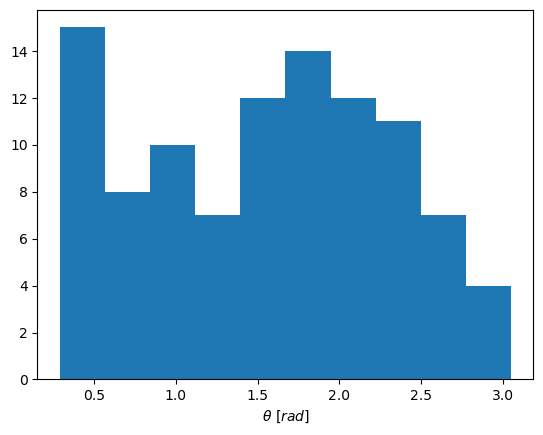

In [36]:
plt.hist(theta)
plt.xlabel(r'$\theta \ [rad]$')

Text(0.5, 0, '$\\phi \\ [rad]$')

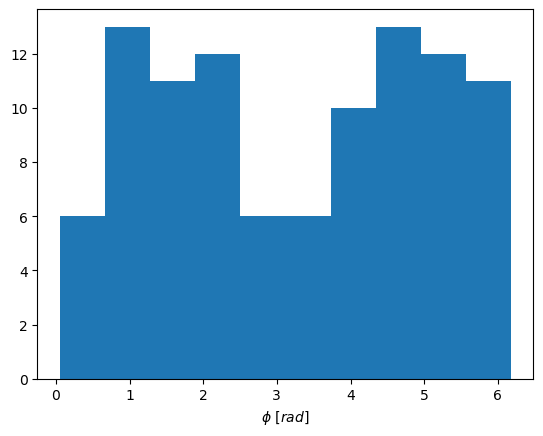

In [37]:
plt.hist(phi)
plt.xlabel(r'$\phi \ [rad]$')

Now let's turn this into (x, y, z) points and fill the initial conditions file, giving each particle a mass of 1 IU.

In [3]:
def spher_to_xyz(radius, t, p):
    x = radius * np.sin(t) * np.cos(p)
    y = radius * np.sin(t) * np.sin(p)
    z = radius * np.cos(t)
    return x, y, z

In [137]:
x_list, y_list, z_list = spher_to_xyz(r, theta, phi)
vx = np.zeros(N_points)
vy = np.zeros(N_points)
vz = np.zeros(N_points)
mass = np.ones(N_points)

# Set up initial conditions

In [138]:
cond_dict = {'m': mass, 'x': x_list, 'y': y_list, 'z': z_list, 'vx': vx, 'vy': vy, 'vz': vz}

In [23]:
def write_ic_in_file(filename, ic_dict, t0=0.0):
    '''
    filename = name of the file where you want the initial conditions
    ic_dict = dictionary containing mass, position and velocity of each particle
    t0 = start time (default=0)
    '''
    N_iter = len(ic_dict['x'])
    
    with open(filename, 'w') as f:  #first say the number of particles and the start time
        f.write(str(N_iter)+'\n')
        f.write(f"{t0:.16e}\n")
        f.close()
    
    for i in range(N_iter):
        x = ic_dict['x'][i]
        y = ic_dict['y'][i]
        z = ic_dict['z'][i]
        vx = ic_dict['vx'][i]
        vy = ic_dict['vy'][i]
        vz = ic_dict['vz'][i]
        m = ic_dict['m'][i]

        with open(filename, 'a') as f:   #append the lines; opening with 'w' overwrites the previous information
            f.write(
            f"{m:.16e} {x:.16e} {y:.16e} {z:.16e} "
            f"{vx:.16e} {vy:.16e} {vz:.16e}\n"
        )

    print('Initial conditions updated. Check your txt file.')

In [139]:
file_path = 'spher_shell_IC.txt'

write_ic_in_file(file_path, cond_dict)

Initial conditions updated. Check your txt file.


# Actual simulation & results

I estimate the collapse time to be: $T_{coll}=\sqrt{\frac{3\pi}{32G\rho_0}}$ where $\rho_0=\frac{\sum_i m_i}{V} \ (i=1...N) = 2.388 \ [IU]$, so that $T_{coll}=0.35 \ [IU]$. 

Does the simulation agree? I will let it run a little longer than the estimated collapse time, just in case.
Maybe I will change it, but for now I will assume that the distribution has collapsed when the mean r reaches its smallest value.

In [67]:
output_path = 'spher_shell_out.txt'

In [26]:
def xyz_to_r(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    return r

In [140]:
data = pd.read_csv(output_path, sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

time_rows = data[data.index % (N_points + 2) - 1 == 0]
times = (time_rows['m']) #only in the 1st lines m is the timestamp, the other 80 times it's the mass of each particle

In [43]:
print(data)

               m         x         y         z         vx         vy  \
0     100.000000       NaN       NaN       NaN        NaN        NaN   
1       0.010002       NaN       NaN       NaN        NaN        NaN   
2       1.000000 -0.141592 -0.756917 -0.219313   0.338281   0.765393   
3       1.000000 -0.253022  0.021226  0.644514   0.084742   0.016175   
4       1.000000  0.662683  0.037813  0.474080  -0.883778  -0.030420   
...          ...       ...       ...       ...        ...        ...   
3055    1.000000 -0.054543 -0.162294 -0.338390   4.767320  -1.109787   
3056    1.000000 -0.100347  0.122360 -0.146559   5.915110  -8.022060   
3057    1.000000  0.348181 -0.334283 -0.256677  -4.081835   2.748736   
3058    1.000000  0.117546 -0.056930 -0.210494  -5.162058   8.720262   
3059    1.000000 -0.082247 -0.103205  0.107606 -15.129551 -12.254560   

             vz  
0           NaN  
1           NaN  
2      0.287850  
3     -0.397727  
4     -0.463871  
...         ...  
3055  14.

In [141]:
# for every timestamp, compute the positions of the particles.

r_values = []

for i in range(len(times)):
    
    r_timestamp = 0
    
    for j in range(N_points):
        particle_rows = data[data.index % (N_points + 2) - (2+j) == 0]
        x = particle_rows['x'][(N_points + 2)*i + j+2]
        y = particle_rows['y'][(N_points + 2)*i + j+2]
        z = particle_rows['z'][(N_points + 2)*i + j+2]
        r = xyz_to_r(x, y, z)
        r_timestamp+=r

    mean_r = r_timestamp/N_points
    r_values.append(mean_r)

Text(0.5, 1.0, 'Evolution of mean radius')

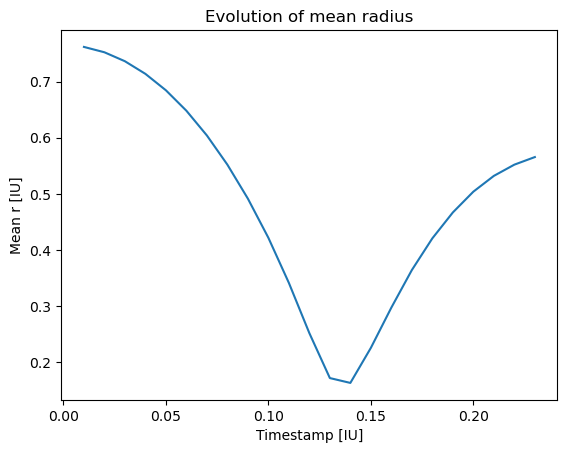

In [142]:
fig, ax = plt.subplots()
plt.plot(times, r_values)
plt.xlabel('Timestamp [IU]')
plt.ylabel('Mean r [IU]')
plt.title('Evolution of mean radius')

In [143]:
sorted_idxs = np.argsort(r_values)
min_idx = sorted_idxs[0]
min_time = times[min_idx*(N_points + 2)+1]
print('Simulated collapse time: ', min_time)
print('Expected collapse time: ', exp_time)

Simulated collapse time:  0.1400010662140618
Expected collapse time:  0.11708024551734543


Let's compare the expected time of collapse to the simulation result for different numbers of bodies

In [150]:
time_path = 'collapse_time_evolution.txt'
time_data = pd.read_csv(time_path, sep=' ', header=None, names=range(3))
time_data.columns = ['N', 'sim_t', 'exp_t']
print (time_data)

     N     sim_t     exp_t
0   70  0.150000  0.132757
1   80  0.136668  0.124182
2   90  0.130001  0.117080
3  100  0.120001  0.111072
4  105  0.120001  0.108395
5  110  0.120001  0.105903


In [149]:
print('mean of 80 bodies times', np.mean([0.1300003468394607, 0.1500014718896245, 0.1300017068314244]))
print('mean of 90 bodies times', np.mean([0.1300018140886082, 0.1200001781966168, 0.1400010662140618]))

mean of 80 bodies times 0.13666784185350322
mean of 90 bodies times 0.13000101949976228


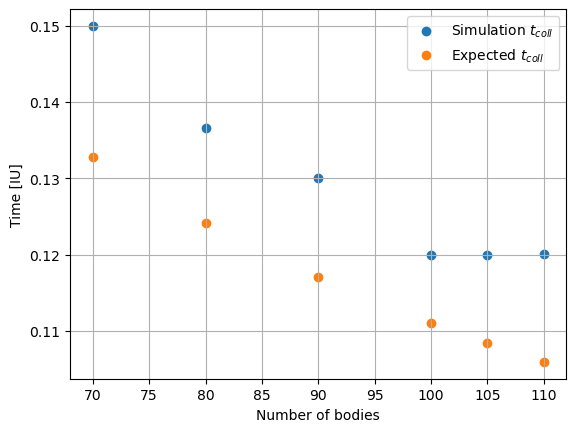

In [151]:
fig, ax = plt.subplots()
plt.scatter(time_data['N'], time_data['sim_t'], label=r'Simulation $t_{coll}$')
plt.scatter(time_data['N'], time_data['exp_t'], label=r'Expected $t_{coll}$')
plt.legend()
plt.xlabel('Number of bodies')
plt.ylabel('Time [IU]')
plt.grid()

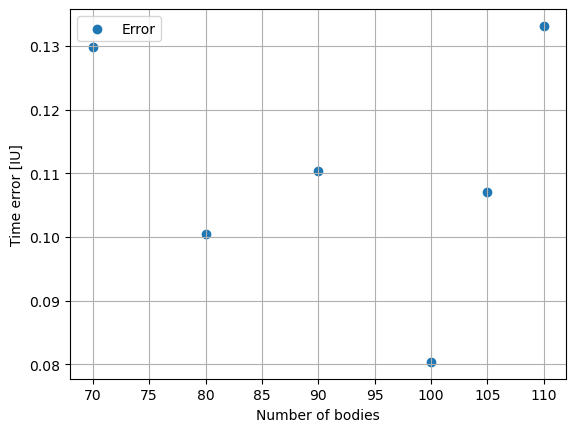

In [153]:
fig, ax = plt.subplots()
plt.scatter(time_data['N'], (time_data['sim_t'] - time_data['exp_t']) / time_data['exp_t'], label='Error')
plt.xlabel('Number of bodies')
plt.ylabel('Time error [IU]')
plt.legend()
plt.grid()